# ST422 Brief 8 — Road Safety Analysis
## Week 8: Data Overview & Preliminary Findings

Draft — Week 8

---

This notebook covers the initial data review for the STATS19 road casualty dataset (2020–2024). The aim this week is to understand the quality and structure of the data before moving into the main analysis. Three datasets are reviewed for quality — collisions, casualties, and vehicles, with preliminary trend analysis on the collision dataset.

> **Note on severity recording:** From around 2016, police forces progressively adopted Injury-Based Reporting Systems (IBRS), which assess injury severity using clinical criteria rather than officer judgement. This means raw serious casualty counts are not directly comparable across years without adjustment. Severity-adjusted figures will be explored by next week.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/zahidahmed/Documents/Stats/ST422/Data'

COLLISION_FILE = f'{DATA_DIR}/dft-road-casualty-statistics-collision-last-5-years.csv'
CASUALTY_FILE  = f'{DATA_DIR}/dft-road-casualty-statistics-casualty-last-5-years.csv'
VEHICLE_FILE   = f'{DATA_DIR}/dft-road-casualty-statistics-vehicle-last-5-years.csv'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'figure.dpi': 120
})

---
## 1. Data Load Summary — Last 5 Years

In [92]:
col = pd.read_csv(COLLISION_FILE, low_memory=False)
cas = pd.read_csv(CASUALTY_FILE,  low_memory=False)
veh = pd.read_csv(VEHICLE_FILE,   low_memory=False)

col.columns = col.columns.str.lower()
cas.columns = cas.columns.str.lower()
veh.columns = veh.columns.str.lower()

print(f'Collision : {len(col):,} rows, {col.shape[1]} columns')
print(f'Casualty  : {len(cas):,} rows, {cas.shape[1]} columns')
print(f'Vehicle   : {len(veh):,} rows, {veh.shape[1]} columns')

Collision : 503,475 rows, 44 columns
Casualty  : 640,522 rows, 23 columns
Vehicle   : 920,692 rows, 32 columns


In [93]:
YEARS = sorted(col['collision_year'].dropna().unique().astype(int).tolist())
COVID_YEARS = [y for y in YEARS if y in [2020, 2021]]

print(f'Years in data : {YEARS}')
print(f'COVID years   : {COVID_YEARS}')

Years in data : [2020, 2021, 2022, 2023, 2024]
COVID years   : [2020, 2021]


In [94]:
# record counts by year across all 3 tables
counts = pd.DataFrame({
    'Year'       : YEARS,
    'Collisions' : [len(col[col['collision_year'] == y]) for y in YEARS],
    'Casualties' : [len(cas[cas['collision_year'] == y]) for y in YEARS],
    'Vehicles'   : [len(veh[veh['collision_year'] == y]) for y in YEARS],
})
counts

,Year,Collisions,Casualties,Vehicles
0,2020,91199,115584,167375
1,2021,101087,128209,186443
2,2022,106004,135480,193545
3,2023,104258,132977,189815
4,2024,100927,128272,183514


Record counts are broadly stable across 2022–2024. The drop in 2020 and 2021 reflects reduced road traffic during COVID-19 restrictions rather than genuine safety improvement — these years are retained for completeness but excluded from any trend-fitting.

---
## 2. Data Quality Checks

Checking all 3 tables. Main things to establish:
- Are key fields badly missing or full of invalid codes?
- How far along is IBRS adoption?
- Any geographic or temporal gaps?

In STATS19, invalid/unknown values are typically coded as **-1** rather than null, the missingness check below treats both as missing.

### 2.1 Data Completeness

The tables below show the proportion of records with missing or invalid values for each key field. In STATS19, unknown or inapplicable values are recorded as **-1** rather than blank — both are treated as missing here. Fields above 5% are flagged.

In [95]:
# fields where negative values are valid (longitude in GB is negative)
NON_NEGATIVE_CHECK = [
    'collision_severity', 'enhanced_severity_collision', 'speed_limit',
    'road_type', 'junction_detail', 'light_conditions', 'urban_or_rural_area',
    'police_force', 'collision_injury_based', 'day_of_week',
    'casualty_severity', 'enhanced_casualty_severity', 'casualty_type',
    'casualty_class', 'age_of_casualty', 'age_band_of_casualty',
    'sex_of_casualty', 'casualty_imd_decile', 'casualty_injury_based',
    'vehicle_type', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver',
    'journey_purpose_of_driver', 'driver_imd_decile', 'propulsion_code', 'escooter_flag',
]

def missingness(df, fields):
    rows = []
    for f in fields:
        if f not in df.columns:
            rows.append({'field': f, 'missing_n': '-', 'missing_pct': '-'})
            continue
        if f in NON_NEGATIVE_CHECK:
            null_mask = df[f].isna() | (pd.to_numeric(df[f], errors='coerce') < 0)
        else:
            null_mask = df[f].isna()
        n   = null_mask.sum()
        pct = n / len(df) * 100
        flag = '  *** high ***' if pct > 5 else ''
        rows.append({'field': f, 'missing_n': f'{n:,}', 'missing_pct': f'{pct:.1f}%{flag}'})
    result = pd.DataFrame(rows)
    result.columns = ['Field', 'Missing (n)', 'Missing (%)']
    return result


In [96]:
# collision — renamed for readability
col_fields = [
    'collision_severity',
    'enhanced_severity_collision',
    'date',
    'time',
    'day_of_week',
    'latitude',
    'longitude',
    'speed_limit',
    'road_type',
    'junction_detail',
    'light_conditions',
    'urban_or_rural_area',
    'police_force',
    'local_authority_ons_district',
    'collision_injury_based',
    'collision_adjusted_severity_serious',
    'collision_adjusted_severity_slight',
]

col_labels = {
    'collision_severity': 'Collision Severity',
    'enhanced_severity_collision': 'Enhanced Severity (new field)',
    'date': 'Date',
    'time': 'Time',
    'day_of_week': 'Day of Week',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'speed_limit': 'Speed Limit',
    'road_type': 'Road Type',
    'junction_detail': 'Junction Detail',
    'light_conditions': 'Light Conditions',
    'urban_or_rural_area': 'Urban / Rural',
    'police_force': 'Police Force',
    'local_authority_ons_district': 'Local Authority (ONS)',
    'collision_injury_based': 'IBRS Recorded',
    'collision_adjusted_severity_serious': 'Adjusted Serious Probability',
    'collision_adjusted_severity_slight': 'Adjusted Slight Probability',
}

miss_col = missingness(col, col_fields)
miss_col['Field'] = miss_col['Field'].map(col_labels).fillna(miss_col['Field'])
print('Collision table:')
miss_col

Collision table:


,Field,Missing (n),Missing (%)
0,Collision Severity,0,0.0%
1,Enhanced Severity (new field),"241,319",47.9% *** high ***
2,Date,0,0.0%
3,Time,0,0.0%
4,Day of Week,0,0.0%
5,Latitude,65,0.0%
6,Longitude,65,0.0%
7,Speed Limit,15,0.0%
8,Road Type,0,0.0%
9,Junction Detail,"14,791",2.9%


In [97]:
cas_fields = [
    'casualty_severity',
    'enhanced_casualty_severity',
    'casualty_type',
    'casualty_class',
    'age_of_casualty',
    'age_band_of_casualty',
    'sex_of_casualty',
    'casualty_imd_decile',
    'casualty_injury_based',
    'casualty_adjusted_severity_serious',
    'casualty_adjusted_severity_slight',
]

cas_labels = {
    'casualty_severity': 'Casualty Severity',
    'enhanced_casualty_severity': 'Enhanced Severity (new field)',
    'casualty_type': 'Road User Type',
    'casualty_class': 'Casualty Class',
    'age_of_casualty': 'Age',
    'age_band_of_casualty': 'Age Band',
    'sex_of_casualty': 'Sex',
    'casualty_imd_decile': 'Deprivation Decile (IMD)',
    'casualty_injury_based': 'IBRS Recorded',
    'casualty_adjusted_severity_serious': 'Adjusted Serious Probability',
    'casualty_adjusted_severity_slight': 'Adjusted Slight Probability',
}

miss_cas = missingness(cas, cas_fields)
miss_cas['Field'] = miss_cas['Field'].map(cas_labels).fillna(miss_cas['Field'])
print('Casualty table:')
miss_cas

Casualty table:


,Field,Missing (n),Missing (%)
0,Casualty Severity,0,0.0%
1,Enhanced Severity (new field),"271,013",42.3% *** high ***
2,Road User Type,"4,935",0.8%
3,Casualty Class,0,0.0%
4,Age,"13,846",2.2%
5,Age Band,"13,846",2.2%
6,Sex,"5,740",0.9%
7,Deprivation Decile (IMD),"69,483",10.8% *** high ***
8,IBRS Recorded,0,0.0%
9,Adjusted Serious Probability,0,0.0%


In [98]:
veh_fields = [
    'vehicle_type',
    'sex_of_driver',
    'age_of_driver',
    'age_band_of_driver',
    'journey_purpose_of_driver',
    'driver_imd_decile',
    'propulsion_code',
    'escooter_flag',
]

veh_labels = {
    'vehicle_type': 'Vehicle Type',
    'sex_of_driver': 'Driver Sex',
    'age_of_driver': 'Driver Age',
    'age_band_of_driver': 'Driver Age Band',
    'journey_purpose_of_driver': 'Journey Purpose',
    'driver_imd_decile': 'Driver Deprivation Decile (IMD)',
    'propulsion_code': 'Propulsion / Fuel Type',
    'escooter_flag': 'E-Scooter Flag',
}

miss_veh = missingness(veh, veh_fields)
miss_veh['Field'] = miss_veh['Field'].map(veh_labels).fillna(miss_veh['Field'])
print('Vehicle table:')
miss_veh

Vehicle table:


,Field,Missing (n),Missing (%)
0,Vehicle Type,"6,545",0.7%
1,Driver Sex,"3,551",0.4%
2,Driver Age,"137,322",14.9% *** high ***
3,Driver Age Band,"137,322",14.9% *** high ***
4,Journey Purpose,"1,827",0.2%
5,Driver Deprivation Decile (IMD),"189,385",20.6% *** high ***
6,Propulsion / Fuel Type,"222,200",24.1% *** high ***
7,E-Scooter Flag,0,0.0%


### 2.2 Severity Recording — IBRS Adoption

The shift from officer-judgement to Injury-Based Reporting Systems (IBRS) is the most important data quality issue for this analysis. Forces on IBRS record more serious casualties because severity is assessed using clinical criteria rather than officer discretion. As adoption increases over time, the proportion of serious casualties may appear to rise — this could reflect improvements in recording accuracy rather than a genuine increase in harm, though both factors may be at play.

The chart below shows what proportion of collisions in each year were recorded under IBRS. Any year significantly below 100% carries greater uncertainty in the adjusted serious figures.

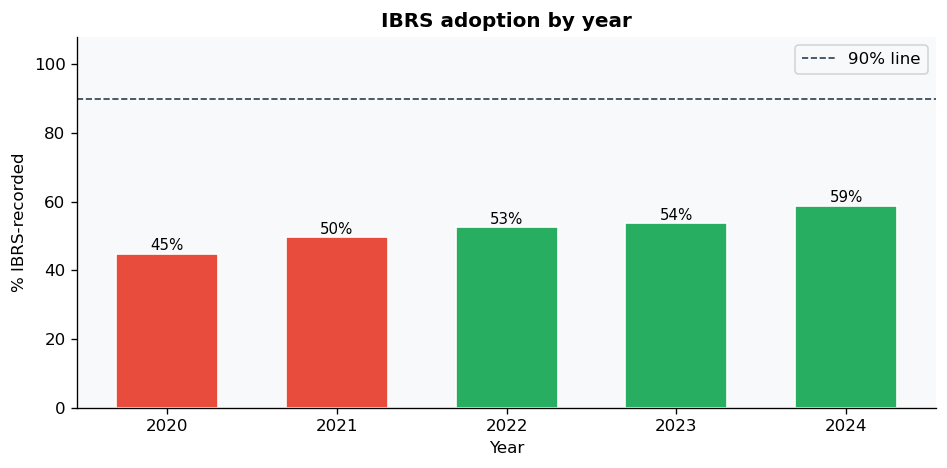

 Year  IBRS Coverage (%)
 2020               44.9
 2021               49.6
 2022               52.6
 2023               53.7
 2024               58.8


In [99]:
ibrs = (
    col.groupby('collision_year')['collision_injury_based']
    .apply(lambda x: (x == 1).sum() / len(x) * 100)
    .reset_index()
)
ibrs.columns = ['year', 'ibrs_pct']
ibrs['ibrs_pct'] = ibrs['ibrs_pct'].round(1)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if y in COVID_YEARS else '#27ae60' for y in ibrs['year']]
bars = ax.bar(ibrs['year'], ibrs['ibrs_pct'], color=colors, width=0.6, edgecolor='white')
ax.axhline(90, color='#2c3e50', linestyle='--', linewidth=1, label='90% line')
for bar, val in zip(bars, ibrs['ibrs_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}%', ha='center', fontsize=9)
ax.set_ylim(0, 108)
ax.set_xlabel('Year')
ax.set_ylabel('% IBRS-recorded')
ax.set_title('IBRS adoption by year', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

ibrs.columns = ['Year', 'IBRS Coverage (%)']

print(ibrs.to_string(index=False))

IBRS adoption has grown from 45% in 2020 to 59% in 2024 but still short of full coverage. This means adjusted severity figures carry meaningful uncertainty, particularly for earlier years. The serious/slight ratio below confirms the recording effect: it has risen steadily from 0.257 to 0.311 over five years, driven primarily by more forces switching to IBRS rather than a genuine change in injury patterns.

In [100]:
sev = col.groupby(['collision_year', 'collision_severity']).size().unstack(fill_value=0)
sev = sev.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
sev['KSI']            = sev['Fatal'] + sev['Serious']
sev['Total']          = sev[['Fatal', 'Serious', 'Slight']].sum(axis=1)
sev['Serious/Slight'] = (sev['Serious'] / sev['Slight']).round(3)
sev['KSI%']           = (sev['KSI'] / sev['Total'] * 100).round(1)

sev_display = sev[['Fatal', 'Serious', 'Slight', 'KSI', 'Serious/Slight', 'KSI%']].copy()
sev_display.index.name = 'Year'
sev_display.columns.name = None
sev_display

,Fatal,Serious,Slight,KSI,Serious/Slight,KSI%
Year,,,,,,
2020,1391,18355,71453,19746,0.257,21.7
2021,1474,21284,78329,22758,0.272,22.5
2022,1602,23333,81069,24935,0.288,23.5
2023,1522,23438,79298,24960,0.296,23.9
2024,1502,23567,75858,25069,0.311,24.8


### 2.3 Geographic Coverage

Checking that all 44 police forces report in every year — gaps would affect any force-level comparisons in the main analysis.

In [101]:
force_yr = col.groupby(['collision_year', 'police_force']).size().unstack(fill_value=0)
forces_per_year = (force_yr > 0).sum(axis=1)
forces_per_year.index.name = 'Year'

print('Forces reporting per year:')
print(forces_per_year.to_string())

gaps = [(int(yr), int(f)) for f in force_yr.columns for yr in force_yr.index if force_yr.loc[yr, f] == 0]
if gaps:
    print(f'\n{len(gaps)} force-year gaps found:')
    for yr, f in gaps[:20]:
        print(f'  Year {yr}, Force code {f}')
else:
    print('\nNo gaps — all forces present in every year')

Forces reporting per year:
Year
2020    44
2021    44
2022    44
2023    44
2024    44

No gaps — all forces present in every year


### 2.4 Location Data Quality

Coordinate completeness is critical for the hotspot mapping planned in next week.

In [102]:
valid   = col['latitude'].notna() & col['longitude'].notna() & (col['latitude'] != 0)
in_gb   = valid & col['latitude'].between(49.5, 61.0) & col['longitude'].between(-8.0, 2.0)
outside = valid.sum() - in_gb.sum()

print(f'Valid coordinates        : {valid.sum():,}  ({valid.sum()/len(col)*100:.1f}%)')
print(f'Within GB bounding box   : {in_gb.sum():,}  ({in_gb.sum()/len(col)*100:.1f}%)')
if outside > 0:
    print(f'Outside GB               : {outside:,}  — worth investigating before spatial work')
else:
    print('All valid coordinates fall within GB')

Valid coordinates        : 503,410  (100.0%)
Within GB bounding box   : 503,410  (100.0%)
All valid coordinates fall within GB


---
## 3. Preliminary Trends

Analysis uses the collision table only this week. Raw severity is used throughout, severity-adjusted KSI will be validated and introduced next week. COVID years are shown but shaded grey and will be excluded from formal trend-fitting.

### 3.1 KSI Trend Over Time

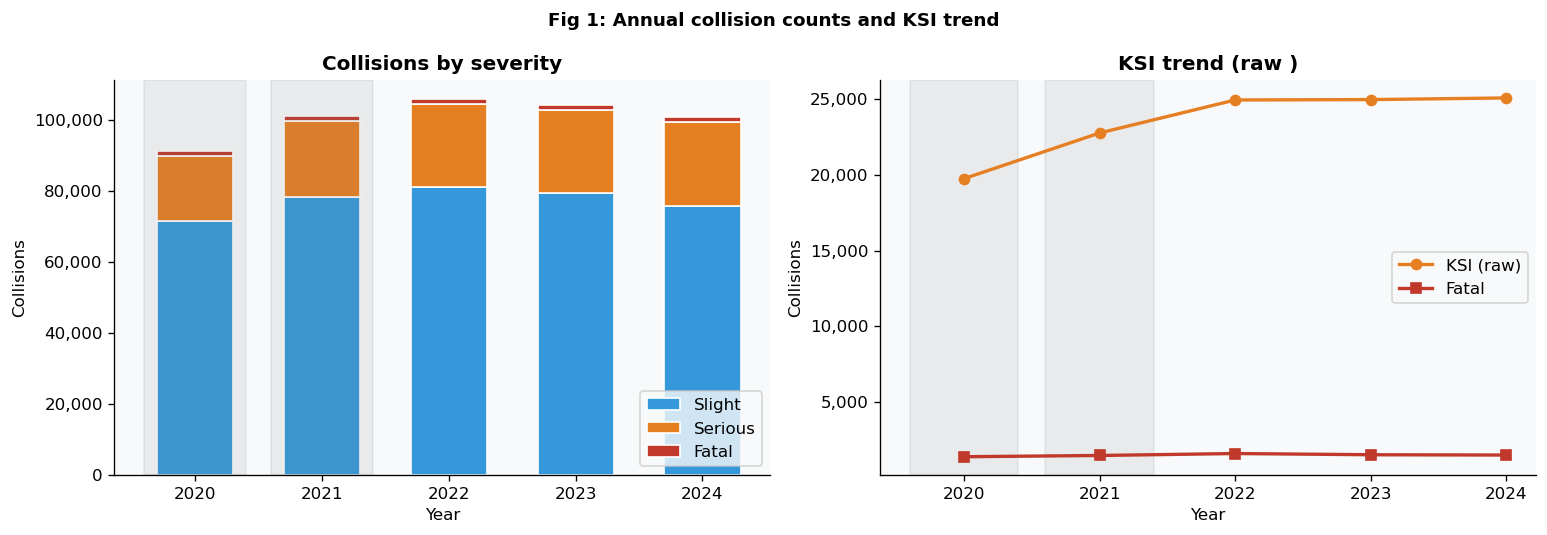

Grey shading = COVID years. Any rise in KSI may partly reflect IBRS adoption, not real change in harm.


In [103]:
by_sev = col.groupby(['collision_year', 'collision_severity']).size().unstack(fill_value=0)
by_sev = by_sev.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
by_sev['KSI'] = by_sev['Fatal'] + by_sev['Serious']
by_sev.index.name = 'Year'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
bottom = np.zeros(len(by_sev))
for sev_label, color in [('Slight', '#3498db'), ('Serious', '#e67e22'), ('Fatal', '#c0392b')]:
    ax.bar(by_sev.index, by_sev[sev_label], bottom=bottom,
           color=color, label=sev_label, width=0.6, edgecolor='white')
    bottom += by_sev[sev_label].values
for yr in COVID_YEARS:
    ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.12, color='grey')
ax.set_title('Collisions by severity', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
ax2.plot(by_sev.index, by_sev['KSI'],   marker='o', color='#e67e22', linewidth=2, label='KSI (raw)')
ax2.plot(by_sev.index, by_sev['Fatal'], marker='s', color='#c0392b', linewidth=2, label='Fatal')
for yr in COVID_YEARS:
    ax2.axvspan(yr - 0.4, yr + 0.4, alpha=0.12, color='grey')
ax2.set_title('KSI trend (raw )', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Collisions')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.legend()

plt.suptitle('Fig 1: Annual collision counts and KSI trend', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Grey shading = COVID years. Any rise in KSI may partly reflect IBRS adoption, not real change in harm.')

### 3.2 Collision Profile — Speed Limit and Road Type

Understanding which speed limits and road types account for the majority of KSI collisions helps scope the hotspot analysis and any intervention recommendations.

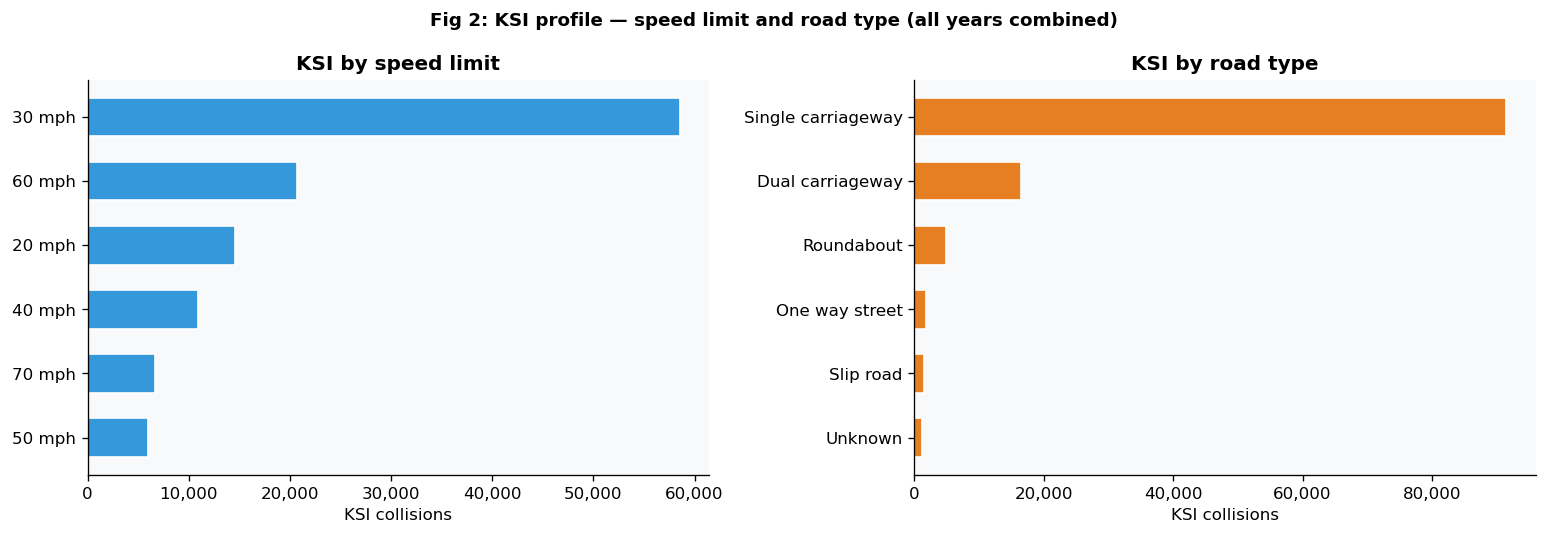

In [104]:
ksi = col[col['collision_severity'].isin([1, 2])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# speed limit — exclude -1 invalid codes
speed = ksi[ksi['speed_limit'] > 0].groupby('speed_limit').size().sort_values(ascending=True)
axes[0].barh([f'{int(s)} mph' for s in speed.index], speed.values,
             color='#3498db', edgecolor='white', height=0.6)
axes[0].set_title('KSI by speed limit', fontweight='bold')
axes[0].set_xlabel('KSI collisions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# road type
rt_map = {
    1: 'Roundabout',
    2: 'One way street',
    3: 'Dual carriageway',
    6: 'Single carriageway',
    7: 'Slip road',
    9: 'Unknown',
    12: 'One way/slip road'
}
ksi['road_type_label'] = ksi['road_type'].map(rt_map).fillna('Other')
rt = ksi.groupby('road_type_label').size().sort_values(ascending=True)
axes[1].barh(rt.index, rt.values, color='#e67e22', edgecolor='white', height=0.6)
axes[1].set_title('KSI by road type', fontweight='bold')
axes[1].set_xlabel('KSI collisions')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Fig 2: KSI profile — speed limit and road type (all years combined)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Temporal Patterns — Day and Time of Day

Identifying when KSI collisions are concentrated is relevant to both contributory factor analysis and the timing of any interventions.

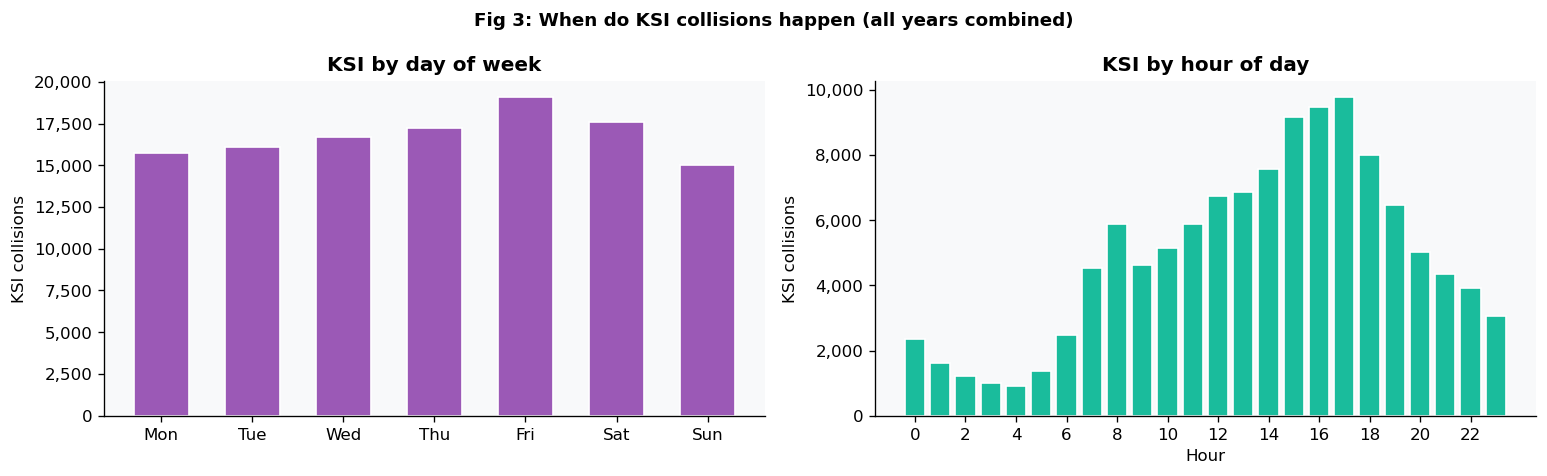

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# day of week — STATS19 codes: 1=Sun, 2=Mon ... 7=Sat
day_map = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
day = ksi['day_of_week'].map(day_map).value_counts().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0].bar(day.index, day.values, color='#9b59b6', edgecolor='white', width=0.6)
axes[0].set_title('KSI by day of week', fontweight='bold')
axes[0].set_ylabel('KSI collisions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# hour of day — time column is HH:MM format
ksi['hour'] = pd.to_datetime(ksi['time'], format='%H:%M', errors='coerce').dt.hour
hour = ksi.groupby('hour').size()
axes[1].bar(hour.index, hour.values, color='#1abc9c', edgecolor='white', width=0.8)
axes[1].set_title('KSI by hour of day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('KSI collisions')
axes[1].set_xticks(range(0, 24, 2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Fig 3: When do KSI collisions happen (all years combined)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Urban vs Rural

In [106]:
ur_map = {1: 'Urban', 2: 'Rural', 3: 'Unallocated'}
col['ur'] = col['urban_or_rural_area'].map(ur_map)

ur = col.groupby(['ur', 'collision_severity']).size().unstack(fill_value=0)
ur = ur.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
ur['KSI']    = ur['Fatal'] + ur['Serious']
ur['Total']  = ur[['Fatal', 'Serious', 'Slight']].sum(axis=1)
ur['KSI%']   = (ur['KSI']   / ur['Total'] * 100).round(1)
ur['Fatal%'] = (ur['Fatal'] / ur['Total'] * 100).round(2)

ur_display = ur[['Fatal', 'Serious', 'Slight', 'KSI', 'KSI%', 'Fatal%']].copy()
ur_display.index.name = 'Area Type'
ur_display.columns.name = None
ur_display

,Fatal,Serious,Slight,KSI,KSI%,Fatal%
Area Type,,,,,,
Rural,4698,42340,116466,47038,28.8,2.87
Unallocated,1,15,44,16,26.7,1.67
Urban,2792,67620,269491,70412,20.7,0.82


Rural collisions are far more deadly despite being fewer in number. Rural KSI rate is 28.8% compared to 20.7% in urban areas, and the rural fatal rate (2.87%) is more than three times the urban rate (0.82%). This likely reflects higher speeds and longer emergency response times. This urban/rural contrast will be an important lens for the hotspot analysis next week.

### 3.5 Casualties by Road User Type

Total collision counts mask important differences in who is being harmed. Car occupants dominate by volume, but the distribution of fatal and serious casualties across road user types points more clearly to where intervention should be targeted.

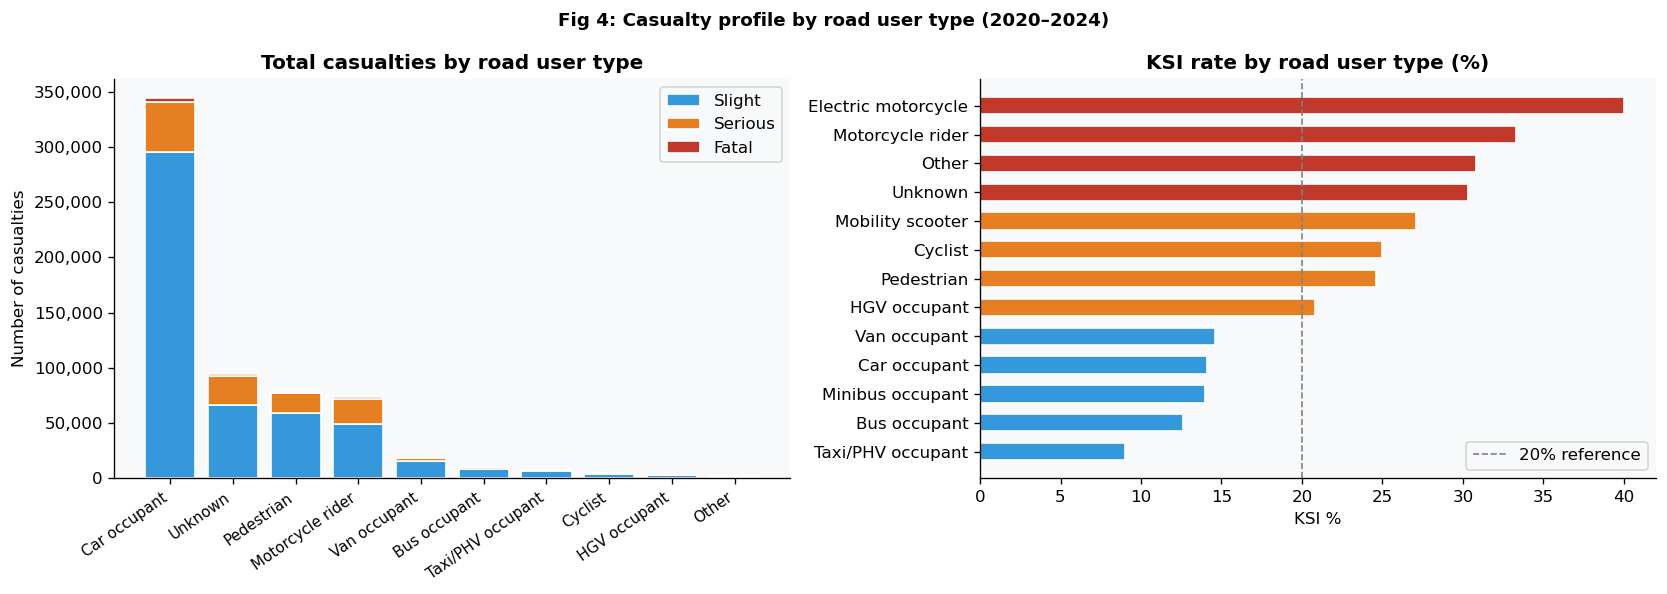

In [107]:
casualty_type_map = {
    1: 'Pedestrian', 2: 'Cyclist', 3: 'Motorcycle rider',
    4: 'Motorcycle rider', 5: 'Motorcycle rider', 8: 'Taxi/PHV occupant',
    9: 'Car occupant', 10: 'Minibus occupant', 11: 'Bus occupant',
    16: 'Horse rider', 17: 'Agricultural vehicle', 18: 'Tram occupant',
    19: 'Van occupant', 20: 'HGV occupant', 21: 'HGV occupant',
    22: 'Mobility scooter', 23: 'Electric motorcycle', 90: 'Other',
    97: 'Motorcycle rider', 98: 'Unknown', 99: 'Unknown'
}

cas['casualty_type_label'] = cas['casualty_type'].map(casualty_type_map).fillna('Unknown')

ct = cas.groupby(['casualty_type_label', 'casualty_severity']).size().unstack(fill_value=0)
ct = ct.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
for c in ['Fatal', 'Serious', 'Slight']:
    if c not in ct.columns:
        ct[c] = 0
ct['Total'] = ct['Fatal'] + ct['Serious'] + ct['Slight']
ct['KSI']   = ct['Fatal'] + ct['Serious']
ct['KSI%']  = (ct['KSI'] / ct['Total'] * 100).round(1)
ct = ct.sort_values('Total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
top = ct.head(10)
bottom = np.zeros(len(top))
for sev, color in [('Slight', '#3498db'), ('Serious', '#e67e22'), ('Fatal', '#c0392b')]:
    ax.bar(range(len(top)), top[sev], bottom=bottom, color=color, label=sev, edgecolor='white')
    bottom += top[sev].values
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Total casualties by road user type', fontweight='bold')
ax.set_ylabel('Number of casualties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
top_ksi = ct[ct['Total'] > 500].sort_values('KSI%', ascending=True)
colors = ['#c0392b' if k > 30 else '#e67e22' if k > 20 else '#3498db' for k in top_ksi['KSI%']]
ax2.barh(top_ksi.index, top_ksi['KSI%'], color=colors, edgecolor='white', height=0.6)
ax2.set_title('KSI rate by road user type (%)', fontweight='bold')
ax2.set_xlabel('KSI %')
ax2.axvline(20, color='grey', linestyle='--', linewidth=1, label='20% reference')
ax2.legend()

plt.suptitle('Fig 4: Casualty profile by road user type (2020–2024)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Pedestrians and motorcycle riders have a disproportionately high KSI rate relative to their total casualty numbers compared to car occupants. Car occupants dominate volume, but the severity profile of pedestrian and motorcycle casualties is considerably worse — this is where intervention effort is most likely to reduce serious harm. Note: the 'Unknown' casualty type group may be material in size — this limits precision of road user targeting recommendations and will be investigated further.

### 3.6 Robustness Check — Does Excluding COVID Years Change the Conclusion?

2020 and 2021 saw sharply reduced traffic due to COVID-19 restrictions. If the post-COVID recovery simply reflects traffic returning to normal, trend conclusions drawn from all five years could be misleading. This check compares trends with and without the COVID years.

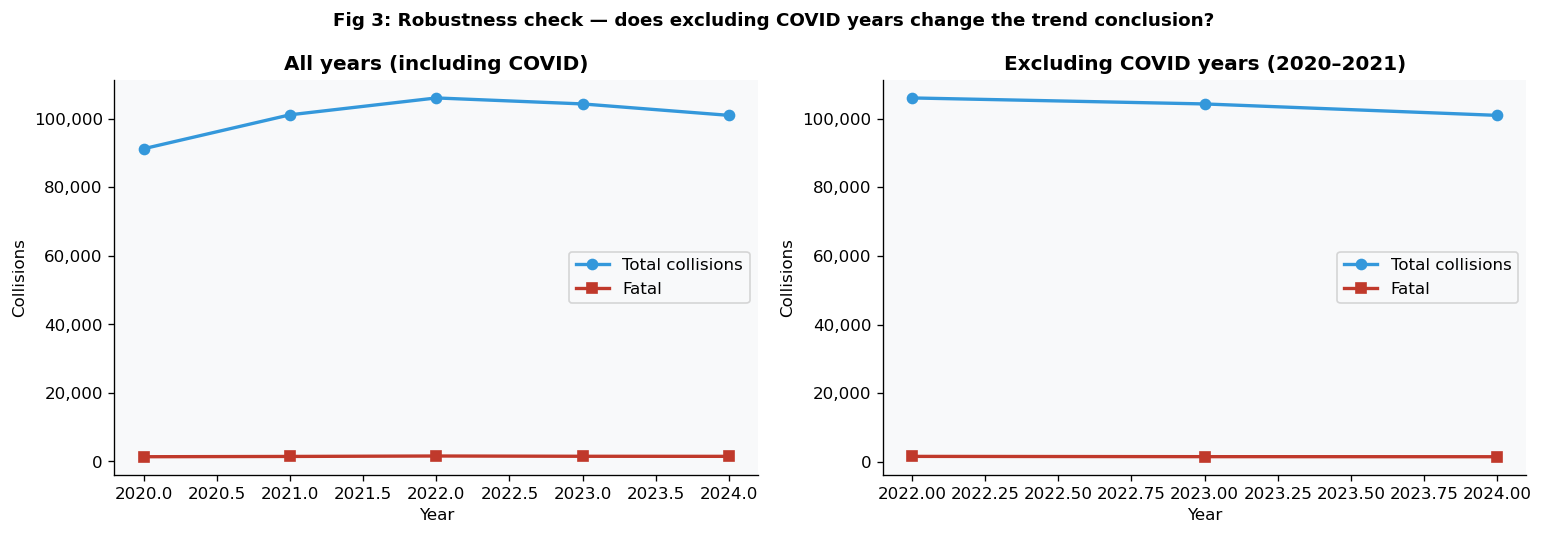

In [108]:
non_covid = col[~col['collision_year'].isin(COVID_YEARS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, df, title in [
    (axes[0], col,       'All years (including COVID)'),
    (axes[1], non_covid, 'Excluding COVID years (2020–2021)')
]:
    s = df.groupby(['collision_year', 'collision_severity']).size().unstack(fill_value=0)
    s = s.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
    s['Total'] = s[['Fatal','Serious','Slight']].sum(axis=1)
    ax.plot(s.index, s['Total'], marker='o', color='#3498db', linewidth=2, label='Total collisions')
    ax.plot(s.index, s['Fatal'], marker='s', color='#c0392b', linewidth=2, label='Fatal')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Collisions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()

plt.suptitle('Fig 3: Robustness check — does excluding COVID years change the trend conclusion?',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Excluding 2020 and 2021 does not change the conclusion — total collisions remain in the 100,000–106,000 range and fatal collisions remain flat at around 1,500 per year. The trend is not an artefact of the COVID dip and recovery. This is the most robust finding this week.

---
## 4. Client Questions

**1. Early indications from the data**

- Fatal collisions appear flat at around 1,500 to 1,700 per year across the window. This finding is not affected by the IBRS transition as fatals are recorded consistently regardless of severity system.
- Rural roads appear disproportionately deadly. KSI rate is 28.8% versus 20.7% urban and the rural fatal rate is more than three times higher (2.87% vs 0.82%), possibly reflecting higher speeds and longer emergency response times. This is based on proportional comparisons within the same year so appears stable to the severity recording issue.
- Car occupants dominate total casualty volume but the more decision relevant finding is that pedestrians and motorcycle riders appear to have a worse severity profile relative to their numbers. This may point to where intervention should be targeted, subject to resolving the Unknown casualty group.
- Excluding COVID years does not materially change the picture, suggesting the trend is not purely driven by traffic volume recovery (Fig 3).
- Key figures to show: urban/rural severity table, casualty by road user type (Fig 4), and the side by side COVID robustness check (Fig 3).

**2. What is still uncertain and why it matters**

- Serious collisions appear to have risen from around 18,000 to 24,000 since 2020 but only 59% of 2024 records use injury based reporting. Some or all of that rise could reflect improvements in recording accuracy rather than a genuine increase in harm, though both factors may be at play.
- The bias runs upward — raw serious counts may be overstated relative to a consistent baseline. If the adjusted trend turns out to be flat, the headline conclusion could change materially.
- The Unknown casualty type group is the second largest category in Fig 4. Until we recode this we cannot make a precise road user targeting recommendation to the client.

**3. Robustness checks**

- Two checks planned: comparing the adjusted KSI series against raw to isolate how much of the serious trend is IBRS driven, and the COVID exclusion check which we have already run and which suggests results hold either way.
- The serious collision trend should be treated as preliminary until adjusted figures are validated next week. The rural finding and the flat fatal trend appear more stable at this stage, though all conclusions remain subject to revision.

**4. Any other business**

- KSI collisions appear concentrated in afternoon and evening hours and on weekdays, consistent with commuter and after-work traffic patterns. This may be relevant to intervention timing but needs further analysis.
- Five years is a short window for trend work. Longer term STATS19 data would likely strengthen any conclusions we take forward and we should flag this to the client.
- Data quality is broadly strong for core fields but deprivation deciles are 11 to 21% missing and propulsion type is missing for 24% of vehicles. Any sub-group analysis using these fields will need caveating.
- Enhanced severity columns are missing for around 48% of collision records and 42% of casualty records, too sparse to use as a primary outcome measure at this stage.